# 📈 Sales Analysis using Matplotlib

## 📖 Project Overview

Data visualization plays a vital role in understanding business performance and supporting data-driven decision-making.

In this project, we analyze the Superstore Sales dataset using **Matplotlib** to uncover valuable business insights. The notebook explores sales trends, profitability, customer behavior, regional performance, product categories, shipping preferences, and discount impact through various visualizations.

The primary objective of this project is to demonstrate how Matplotlib can be used to perform Exploratory Data Analysis (EDA) and transform raw business data into meaningful visual insights.

---

## 🎯 Objectives

By the end of this project, we will:

- Load and explore a real-world sales dataset.
- Clean and prepare the data for analysis.
- Analyze sales and profit trends.
- Compare different product categories and customer segments.
- Evaluate regional business performance.
- Understand the impact of discounts on profitability.
- Draw meaningful business insights through visualizations.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline

In [3]:
df = pd.read_csv(r"C:\Users\Anupa\Desktop\Python-Data-Visualization\Python-Data-Visualization\Datasets/superstore.csv")

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2017-152156,11/8/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2.0,0.00,41.9136
1,2,CA-2017-152156,11/8/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3.0,0.00,219.5820
2,3,CA-2017-138688,6/12/2017,6/16/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2.0,0.00,6.8714
3,4,US-2016-108966,10/11/2016,10/18/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5.0,0.45,-383.0310
4,5,US-2016-108966,10/11/2016,10/18/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2.0,0.20,2.5164


# 📊 Dataset Overview

Before beginning the visualization process, it is important to understand the structure and quality of the dataset.

In this section, we will examine:

- Number of rows and columns
- Data types of each feature
- Numerical summary statistics
- Categorical summary statistics
- Missing values

This initial exploration helps us understand the dataset before performing any analysis.

In [4]:
df.shape

(10800, 21)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10800 entries, 0 to 10799
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         10800 non-null  str    
 1   Order ID       10800 non-null  str    
 2   Order Date     9994 non-null   str    
 3   Ship Date      9994 non-null   str    
 4   Ship Mode      9994 non-null   str    
 5   Customer ID    9994 non-null   str    
 6   Customer Name  9994 non-null   str    
 7   Segment        9994 non-null   str    
 8   Country        9994 non-null   str    
 9   City           9994 non-null   str    
 10  State          9994 non-null   str    
 11  Postal Code    9983 non-null   float64
 12  Region         9994 non-null   str    
 13  Product ID     9994 non-null   str    
 14  Category       9994 non-null   str    
 15  Sub-Category   9994 non-null   str    
 16  Product Name   9994 non-null   str    
 17  Sales          9994 non-null   float64
 18  Quantity       99

In [6]:
df.describe()

,Postal Code,Sales,Quantity,Discount,Profit
count,9983.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,55245.233297,229.858001,3.789574,0.156203,28.656896
std,32038.715955,623.245101,2.225110,0.206452,234.260108
min,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,57103.000000,54.490000,3.000000,0.200000,8.666500
75%,90008.000000,209.940000,5.000000,0.200000,29.364000
max,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [7]:
df.describe(include=["object", "string"])

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Region,Product ID,Category,Sub-Category,Product Name
count,10800,10800,9994,9994,9994,9994,9994,9994,9994,9994,9994,9994,9994,9994,9994,9994
unique,10001,5015,1236,1334,4,793,793,3,1,531,49,4,1862,3,17,1850
top,Yes,CA-2018-100111,9/5/2017,12/16/2016,Standard Class,WB-21850,William Brown,Consumer,United States,New York City,California,West,OFF-PA-10001970,Office Supplies,Binders,Staple envelope
freq,800,28,38,35,5968,37,37,5191,9994,915,2001,3203,19,6026,1523,48


In [8]:
df.isnull().sum()

Row ID             0
Order ID           0
Order Date       806
Ship Date        806
Ship Mode        806
Customer ID      806
Customer Name    806
Segment          806
Country          806
City             806
State            806
Postal Code      817
Region           806
Product ID       806
Category         806
Sub-Category     806
Product Name     806
Sales            806
Quantity         806
Discount         806
Profit           806
dtype: int64

# 🧹 Data Cleaning

Data cleaning is an essential step before visualization.

In this section, we check the dataset for:

- Duplicate records
- Missing values
- Data consistency

Removing unnecessary duplicates ensures that our analysis is accurate and reliable.

In [9]:
df.duplicated().sum()

np.int64(504)

In [10]:
df.drop_duplicates(inplace=True)

In [11]:
df.info()

<class 'pandas.DataFrame'>
Index: 10296 entries, 0 to 10798
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         10296 non-null  str    
 1   Order ID       10296 non-null  str    
 2   Order Date     9994 non-null   str    
 3   Ship Date      9994 non-null   str    
 4   Ship Mode      9994 non-null   str    
 5   Customer ID    9994 non-null   str    
 6   Customer Name  9994 non-null   str    
 7   Segment        9994 non-null   str    
 8   Country        9994 non-null   str    
 9   City           9994 non-null   str    
 10  State          9994 non-null   str    
 11  Postal Code    9983 non-null   float64
 12  Region         9994 non-null   str    
 13  Product ID     9994 non-null   str    
 14  Category       9994 non-null   str    
 15  Sub-Category   9994 non-null   str    
 16  Product Name   9994 non-null   str    
 17  Sales          9994 non-null   float64
 18  Quantity       9994 no

# 📈 Exploratory Data Analysis (EDA)

After cleaning the dataset, we begin exploring the data through various visualizations.

The following analysis focuses on:

- Sales distribution
- Monthly sales and profit trends
- Category-wise performance
- Regional analysis
- Customer segments
- Shipping preferences
- Product performance
- Discount impact
- Relationship between sales and profit

Each visualization is followed by a brief business observation.

In [12]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2017-152156,11/8/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2.0,0.00,41.9136
1,2,CA-2017-152156,11/8/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3.0,0.00,219.5820
2,3,CA-2017-138688,6/12/2017,6/16/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2.0,0.00,6.8714
3,4,US-2016-108966,10/11/2016,10/18/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5.0,0.45,-383.0310
4,5,US-2016-108966,10/11/2016,10/18/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2.0,0.20,2.5164


In [13]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='str')

# 💰 Sales Distribution

Understanding the distribution of sales is essential for identifying customer purchasing patterns and detecting unusual transactions.

This histogram helps us analyze:

- The overall distribution of sales values.
- The most common sales range across customer orders.
- The presence of high-value sales outliers.
- The shape and spread of the sales distribution.
- The relationship between the mean and median sales values.

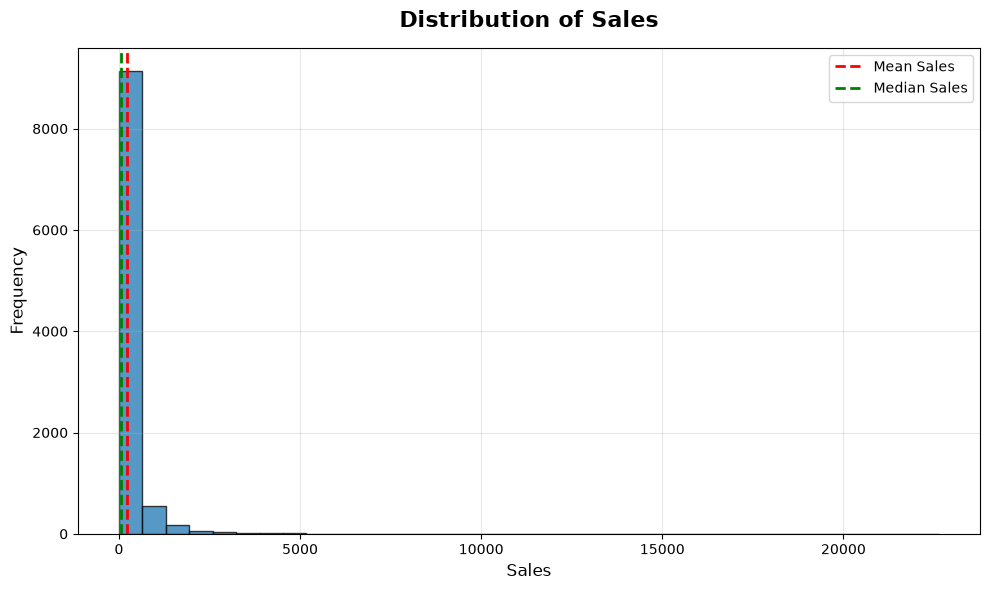

In [38]:
# This histogram shows how sales values are distributed across customer orders.

plt.figure(figsize=(10,6))

plt.hist(
    df["Sales"],
    bins=35,
    edgecolor="black",
    alpha=0.75
)

plt.axvline(
    df["Sales"].mean(),
    color="red",
    linestyle="--",
    linewidth=2,
    label="Mean Sales"
)

plt.axvline(
    df["Sales"].median(),
    color="green",
    linestyle="--",
    linewidth=2,
    label="Median Sales"
)

plt.title(
    "Distribution of Sales",
    fontsize=16,
    weight="bold",
    pad=15
)

plt.xlabel("Sales", fontsize=12)

plt.ylabel("Frequency", fontsize=12)

plt.grid(alpha=0.3)

plt.legend()

plt.tight_layout()

plt.show()

### 📌 Observation

- The distribution of sales is **positively (right) skewed**, indicating that most orders have relatively low sales values.
- A small number of orders generate exceptionally high sales, creating a long right tail in the distribution.
- The **mean sales** is higher than the **median sales**, confirming the presence of high-value sales outliers.
- This suggests that while the majority of transactions are small, a few large orders contribute significantly to the overall sales revenue.

# 📅 Monthly Sales Trend

Analyzing monthly sales helps us understand how business performance changes over time. It allows us to identify growth patterns, seasonal fluctuations, and periods of strong or weak sales performance.

This visualization helps us analyze:

- Overall sales trends across different months.
- Seasonal patterns in customer purchasing behavior.
- Months with the highest and lowest sales.
- Changes in business performance over time.
- Opportunities for improving sales during low-performing periods.

In [ ]:
#checking the dtype

print(df["Order Date"].dtype)

str


In [17]:
# Coverting Order Date into datetime datatype
df["Order Date"] = pd.to_datetime(df["Order Date"])

# Extract Year-Month
df["Year_Month"] = df["Order Date"].dt.to_period("M").astype(str)

monthly_sales = df.groupby("Year_Month")["Sales"].sum()

monthly_sales.head()

Year_Month
2015-01    14236.895
2015-02     4519.892
2015-03    55691.009
2015-04    28295.345
2015-05    23648.287
Name: Sales, dtype: float64

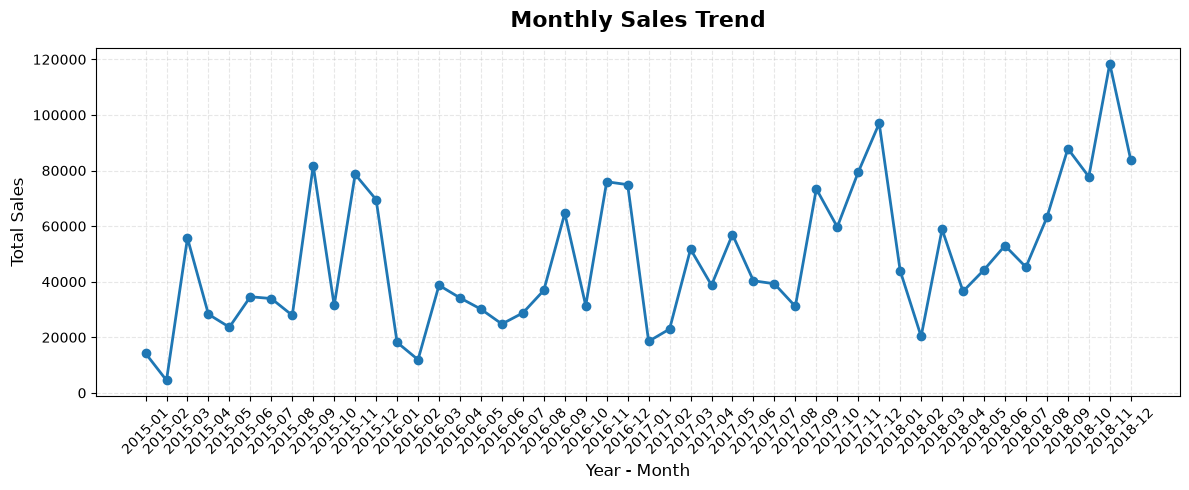

In [40]:
plt.figure(figsize=(12,5))

plt.plot(
    monthly_sales.index,
    monthly_sales.values,
    marker="o",
    linewidth=2
)


plt.title(
    "Monthly Sales Trend",
    fontsize=16,
    weight="bold",
    pad=15
)

plt.xlabel(
    "Year - Month",
    fontsize=12
)

plt.ylabel(
    "Total Sales",
    fontsize=12
)

plt.xticks(rotation=45)

plt.grid(
    alpha=0.3,
    linestyle="--"
)

plt.tight_layout()

plt.show()

### 📌 Observation

- Monthly sales fluctuate over time, indicating variations in customer demand.
- Certain months experience significantly higher sales, suggesting periods of strong business performance.
- Some months show comparatively lower sales, which may indicate seasonal slowdowns or reduced customer activity.
- Overall, the trend highlights changing sales patterns that can help businesses identify peak seasons and improve planning for low-performing periods.

# 💰 Monthly Profit Trend

Analyzing monthly profit is essential for evaluating the financial health of a business. While sales indicate revenue generation, profit reflects the actual earnings after accounting for costs and expenses.

This visualization helps us analyze:

- Monthly changes in profit over time.
- Periods of high and low profitability.
- Overall profit trends throughout the year.
- Business performance beyond sales revenue.
- Opportunities to improve profitability during low-performing months.

In [19]:
monthly_profit = df.groupby("Year_Month")["Profit"].sum()

monthly_profit.head()

Year_Month
2015-01    2450.1907
2015-02     862.3084
2015-03     498.7299
2015-04    3488.8352
2015-05    2738.7096
Name: Profit, dtype: float64

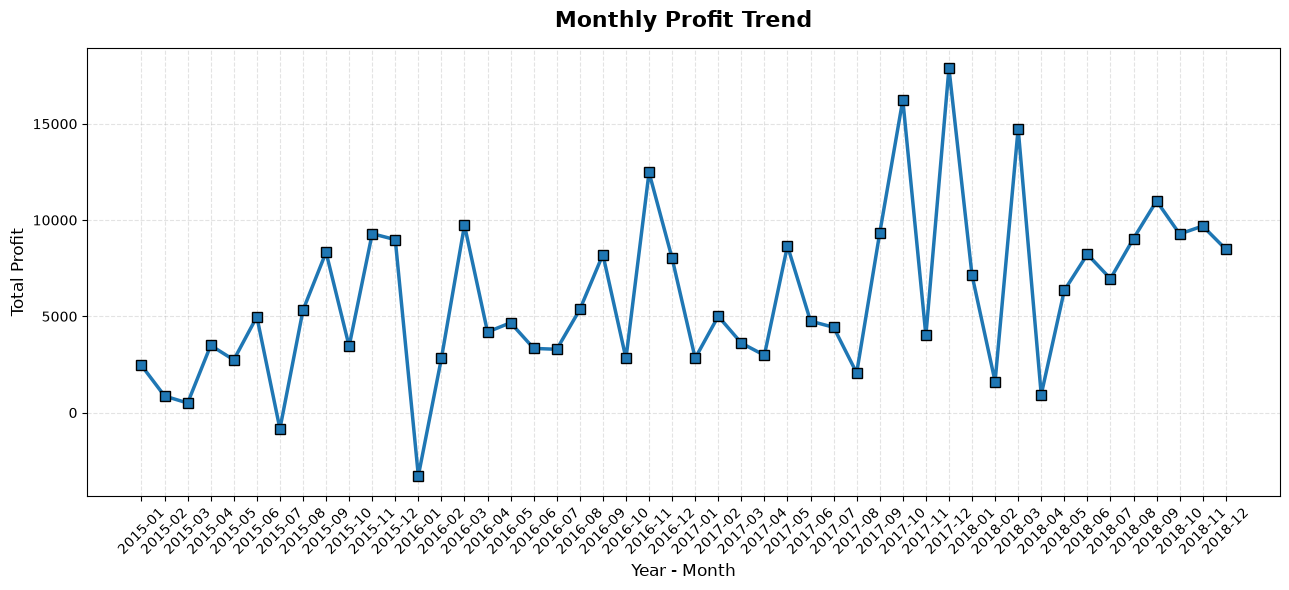

In [ ]:
plt.figure(figsize=(13,6))

plt.plot(
    monthly_profit.index,
    monthly_profit.values,
    marker="s",
    markersize=7,
    linewidth=2.5,
    markeredgecolor="black"
)

plt.title(
    "Monthly Profit Trend",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.xlabel(
    "Year - Month",
    fontsize=12
)

plt.ylabel(
    "Total Profit",
    fontsize=12
)

plt.xticks(
    rotation=45,
    fontsize=10
)

plt.yticks(fontsize=10)

plt.grid(
    linestyle="--",
    alpha=0.35
)

plt.tight_layout()

plt.show()

### 📌 Observation

- Monthly profit varies over time, indicating fluctuations in business profitability.
- Some months generate significantly higher profits, reflecting periods of strong financial performance.
- A few months record comparatively lower profits, suggesting reduced margins or increased business costs.
- Monitoring monthly profit trends helps businesses evaluate financial performance, identify profitable periods, and make better strategic decisions.

# 🛍️ Sales by Category

Analyzing sales across different product categories helps us understand which categories contribute the most to overall business revenue. This comparison highlights customer preferences and supports better inventory and marketing decisions.

This visualization helps us analyze:

- Total sales generated by each product category.
- The highest and lowest revenue-contributing categories.
- Customer purchasing preferences across categories.
- The relative contribution of each category to total sales.
- Business opportunities for improving category performance.

In [21]:
category_sales = df.groupby("Category")["Sales"].sum()

category_sales

Category
Furniture          741999.7953
Office Supplies    719047.0320
Technology         836154.0330
Name: Sales, dtype: float64

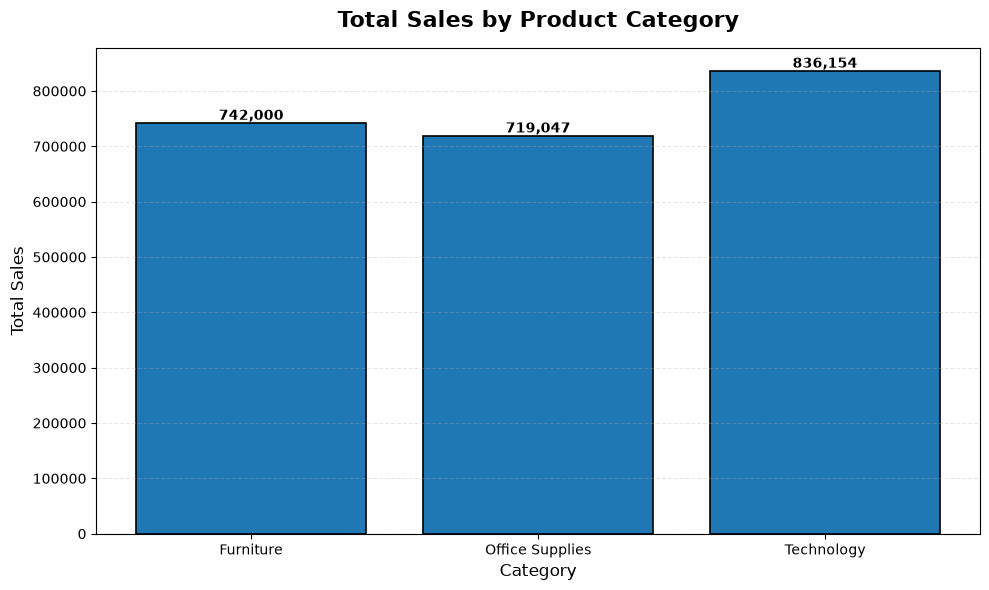

In [42]:
plt.figure(figsize=(10,6))

bars = plt.bar(
    category_sales.index,
    category_sales.values,
    edgecolor="black",
    linewidth=1.2
)


plt.title(
    "Total Sales by Product Category",
    fontsize=16,
    fontweight="bold",
    pad=15
)


plt.xlabel(
    "Category",
    fontsize=12
)

plt.ylabel(
    "Total Sales",
    fontsize=12
)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)


for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{bar.get_height():,.0f}",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

plt.tight_layout()

plt.show()

### 📌 Observation

- The **Technology** category generated the highest total sales (**836,154**), making it the strongest contributor to overall revenue.
- **Furniture** recorded the second-highest sales (**742,000**), indicating strong customer demand.
- **Office Supplies** generated the lowest sales (**719,047**) among the three categories.
- Although the difference between **Furniture** and **Office Supplies** is relatively small, **Technology** clearly outperformed both categories.
- The results suggest that technology products are the primary revenue driver, while the other categories also contribute significantly to the overall business performance.

# 💵 Profit by Category

Analyzing profit across different product categories helps us evaluate which categories generate the highest earnings, rather than just high sales. This comparison provides valuable insights into the financial performance of each category.

This visualization helps us analyze:

- Total profit generated by each product category.
- The most and least profitable categories.
- Differences between sales performance and profitability.
- The financial contribution of each category.
- Opportunities to improve profitability across product categories.

In [23]:
category_profit = df.groupby("Category")["Profit"].sum()

category_profit

Category
Furniture           18451.2728
Office Supplies    122490.8008
Technology         145454.9481
Name: Profit, dtype: float64

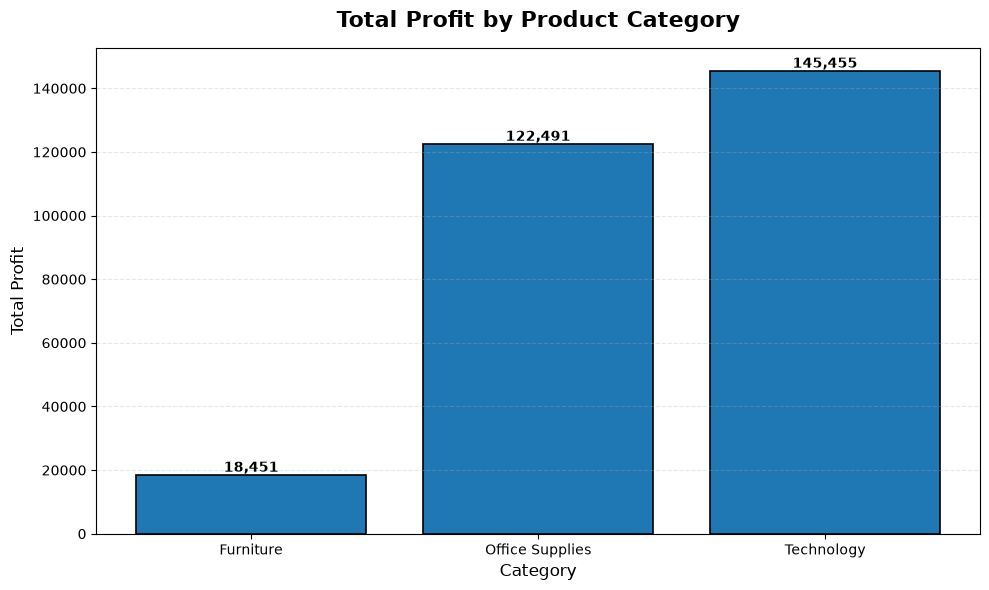

In [43]:
plt.figure(figsize=(10,6))

bars = plt.bar(
    category_profit.index,
    category_profit.values,
    edgecolor="black",
    linewidth=1.2
)

plt.title(
    "Total Profit by Product Category",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.xlabel(
    "Category",
    fontsize=12
)

plt.ylabel(
    "Total Profit",
    fontsize=12
)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{bar.get_height():,.0f}",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

plt.tight_layout()

plt.show()

### 📌 Observation

- The **Technology** category generated the highest total profit (**145,455**), making it the most profitable product category.
- **Office Supplies** recorded the second-highest profit (**122,491**), demonstrating strong and consistent profitability.
- **Furniture** generated the lowest profit (**18,451**), despite contributing substantial sales in the previous analysis.
- The large gap in profit between **Furniture** and the other categories suggests that high sales do not necessarily translate into high profitability.
- Overall, **Technology** delivers the best financial performance, while **Furniture** may require improvements in pricing, discount strategies, or cost management to increase profitability.

# 🌍 Regional Sales Analysis

Analyzing sales across different regions helps us understand the geographical performance of the business. It enables us to identify regions that generate the highest revenue and those that may require additional attention or improvement.

This visualization helps us analyze:

- Total sales generated by each region.
- The highest and lowest revenue-performing regions.
- Regional differences in sales performance.
- Customer demand across different geographical areas.
- Opportunities to improve sales in underperforming regions.

In [25]:
region_sales = df.groupby("Region")["Sales"].sum()

region_sales

Region
Central    501239.8908
East       678781.2400
South      391721.9050
West       725457.8245
Name: Sales, dtype: float64

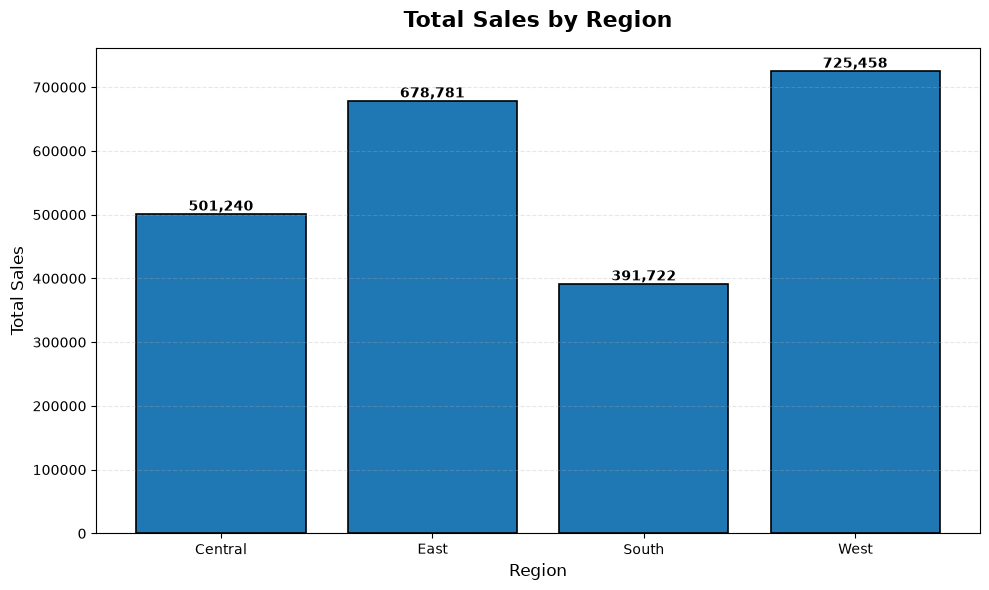

In [44]:
plt.figure(figsize=(10,6))

bars = plt.bar(
    region_sales.index,
    region_sales.values,
    edgecolor="black",
    linewidth=1.2
)

plt.title(
    "Total Sales by Region",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.xlabel(
    "Region",
    fontsize=12
)

plt.ylabel(
    "Total Sales",
    fontsize=12
)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{bar.get_height():,.0f}",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

plt.tight_layout()

plt.show()

### 📌 Observation

- The **West** region generated the highest total sales (**725,458**), making it the strongest-performing region.
- The **East** region ranked second with **678,781** in total sales, indicating consistently strong customer demand.
- The **Central** region contributed **501,240** in sales, reflecting moderate business performance.
- The **South** region recorded the lowest total sales (**391,722**), suggesting comparatively lower market performance.
- Overall, the **West** and **East** regions are the primary contributors to the company's revenue, while the **South** region presents opportunities for business growth and targeted sales improvement.

# 👥 Customer Segment Analysis

Understanding customer segments helps businesses identify which groups contribute the most to overall sales. Analyzing customer behavior across different segments enables organizations to develop targeted marketing strategies and improve customer satisfaction.

This visualization helps us analyze:

- Total sales generated by each customer segment.
- The highest and lowest revenue-contributing segments.
- Customer purchasing patterns across different segments.
- The contribution of each segment to overall business revenue.
- Opportunities to strengthen engagement with underperforming customer segments.

In [28]:
segment_sales = df.groupby("Segment")["Sales"].sum()

segment_sales

Segment
Consumer       1.161401e+06
Corporate      7.061464e+05
Home Office    4.296531e+05
Name: Sales, dtype: float64

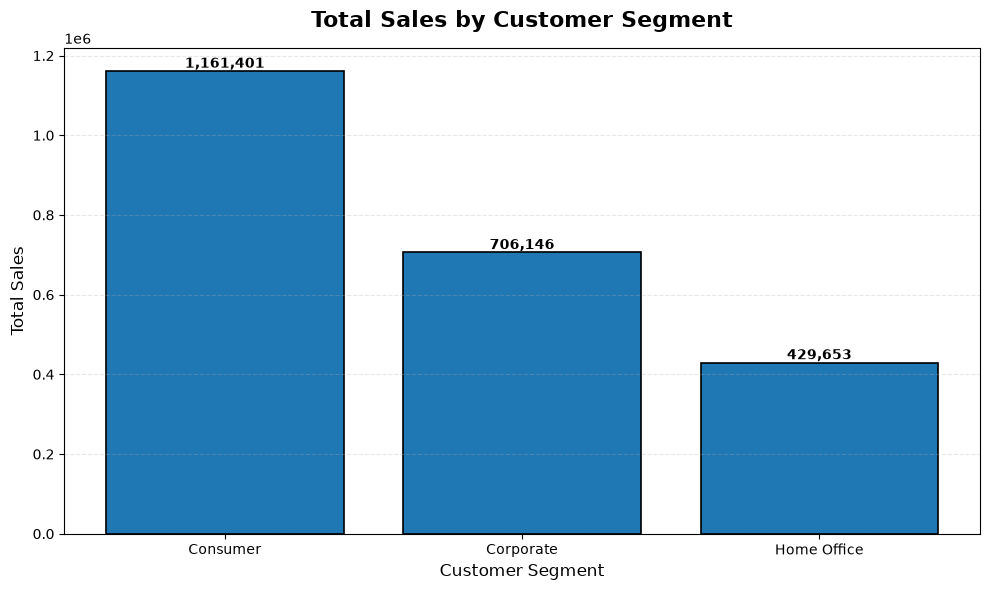

In [47]:
plt.figure(figsize=(10,6))

bars = plt.bar(
    segment_sales.index,
    segment_sales.values,
    edgecolor="black",
    linewidth=1.2
)

plt.title(
    "Total Sales by Customer Segment",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.xlabel(
    "Customer Segment",
    fontsize=12
)

plt.ylabel(
    "Total Sales",
    fontsize=12
)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{bar.get_height():,.0f}",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

plt.tight_layout()

plt.show()

### 📌 Observation

- The **Consumer** segment generated the highest total sales (**1,161,401**), making it the largest contributor to the company's overall revenue.
- The **Corporate** segment recorded the second-highest sales (**706,146**), indicating strong business demand from corporate customers.
- The **Home Office** segment generated the lowest sales (**429,653**) among the three customer segments.
- The Consumer segment significantly outperformed both the Corporate and Home Office segments, highlighting its importance to the business.
- Overall, the results suggest that individual consumers are the company's primary customer base, while the Corporate and Home Office segments offer opportunities for further sales growth.

# 🚚 Shipping Mode Analysis

Shipping mode plays an important role in customer satisfaction, delivery efficiency, and operational costs. Analyzing the distribution of orders across different shipping modes helps us understand customer preferences and the company's shipping strategy.

This visualization helps us analyze:

- The number of orders placed through each shipping mode.
- The most and least frequently used shipping methods.
- Customer preferences for delivery options.
- The distribution of orders across available shipping modes.
- Opportunities to optimize shipping operations and improve customer experience.

In [30]:
ship_mode = df["Ship Mode"].value_counts()

ship_mode

Ship Mode
Standard Class    5968
Second Class      1945
First Class       1538
Same Day           543
Name: count, dtype: int64

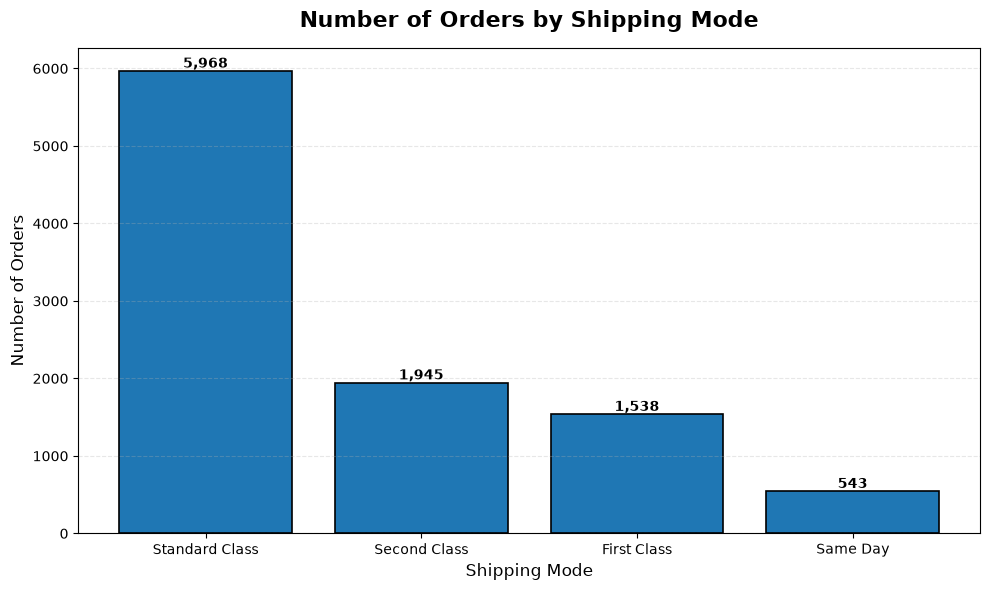

In [49]:
plt.figure(figsize=(10,6))

bars = plt.bar(
    ship_mode.index,
    ship_mode.values,
    edgecolor="black",
    linewidth=1.2
)

plt.title(
    "Number of Orders by Shipping Mode",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.xlabel(
    "Shipping Mode",
    fontsize=12
)

plt.ylabel(
    "Number of Orders",
    fontsize=12
)

plt.xticks(
    fontsize=10
)

plt.yticks(fontsize=10)


plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)


for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{bar.get_height():,}",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

plt.tight_layout()

plt.show()

### 📌 Observation

- **Standard Class** is the most preferred shipping mode, accounting for **5,968 orders**, which is significantly higher than all other shipping options.
- **Second Class** ranks second with **1,945 orders**, followed by **First Class** with **1,538 orders**.
- **Same Day** shipping is the least frequently used option, with only **543 orders**.
- The large difference in order counts indicates that most customers prefer cost-effective standard delivery over faster shipping services.
- Overall, the results suggest that **Standard Class** is the company's primary shipping method and plays a crucial role in fulfilling customer orders efficiently.

# 🏆 Top 10 Products by Sales

Identifying the top-selling products helps businesses understand which items contribute the most to overall revenue. This analysis supports inventory planning, product promotion, and strategic decision-making by highlighting the best-performing products.

This visualization helps us analyze:

- The top 10 products based on total sales.
- Products that generate the highest revenue.
- Differences in sales performance among leading products.
- Customer demand for high-performing products.
- Opportunities to prioritize inventory and marketing efforts for top-selling products.

In [33]:
top_products = (
    df.groupby("Product Name")["Sales"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

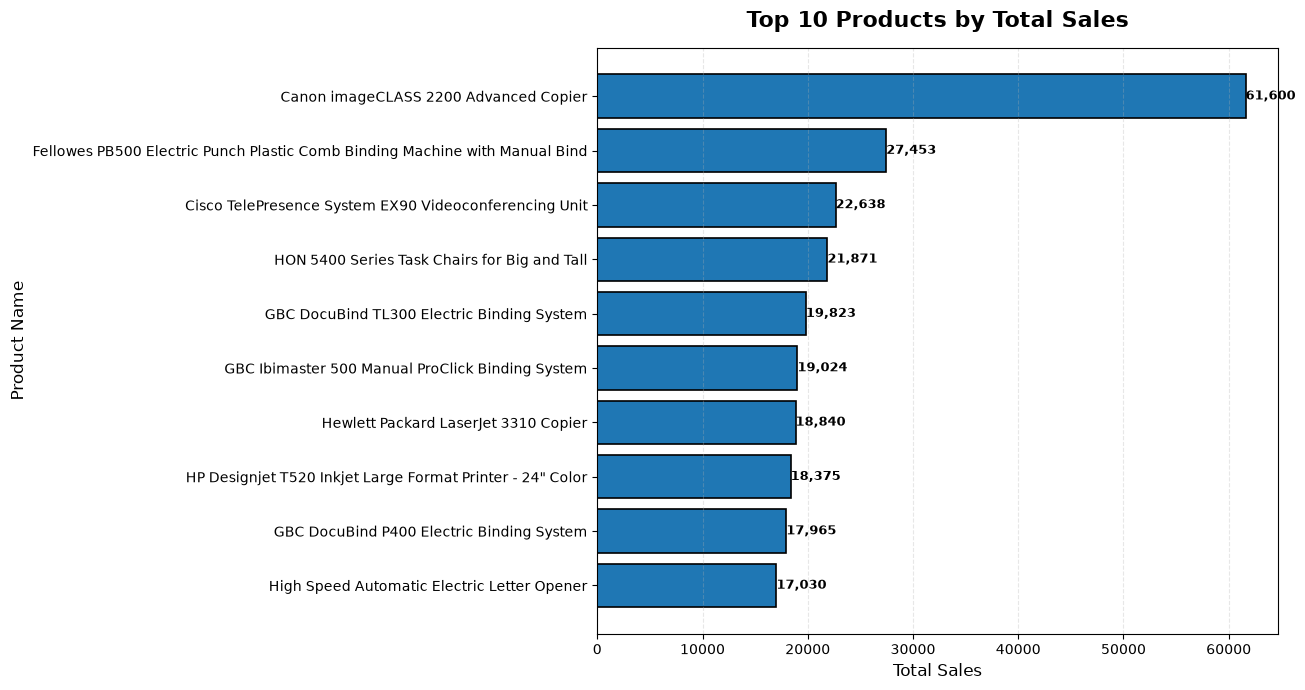

In [50]:
plt.figure(figsize=(13,7))

bars = plt.barh(
    top_products.index,
    top_products.values,
    edgecolor="black",
    linewidth=1.2
)

plt.gca().invert_yaxis()

plt.title(
    "Top 10 Products by Total Sales",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.xlabel(
    "Total Sales",
    fontsize=12
)

plt.ylabel(
    "Product Name",
    fontsize=12
)

plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.3
)

for bar in bars:
    plt.text(
        bar.get_width(),
        bar.get_y() + bar.get_height()/2,
        f"{bar.get_width():,.0f}",
        va="center",
        ha="left",
        fontsize=9,
        fontweight="bold"
    )

plt.tight_layout()

plt.show()

### 📌 Observation

- The **Canon imageCLASS 2200 Advanced Copier** is the highest-selling product, generating approximately **61,600** in total sales, significantly outperforming all other products.
- The **Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind** ranks second with approximately **27,453** in sales.
- The remaining products generated sales ranging from **17,030** to **22,638**, indicating relatively similar performance among the other top-selling products.
- The substantial gap between the first and second-ranked products highlights the exceptional demand for the **Canon imageCLASS 2200 Advanced Copier**.
- Overall, the top 10 products contribute significantly to the company's revenue and represent the business's highest-performing products.

# 📉 Discount vs Profit

Understanding the relationship between discounts and profit is essential for evaluating pricing strategies. While discounts can attract more customers and increase sales, excessive discounts may reduce overall profitability.

This visualization helps us analyze:

- The relationship between discount and profit.
- Whether higher discounts lead to lower profits.
- The impact of discounting on business performance.
- Patterns and trends between pricing and profitability.
- Opportunities to optimize discount strategies while maintaining healthy profit margins.

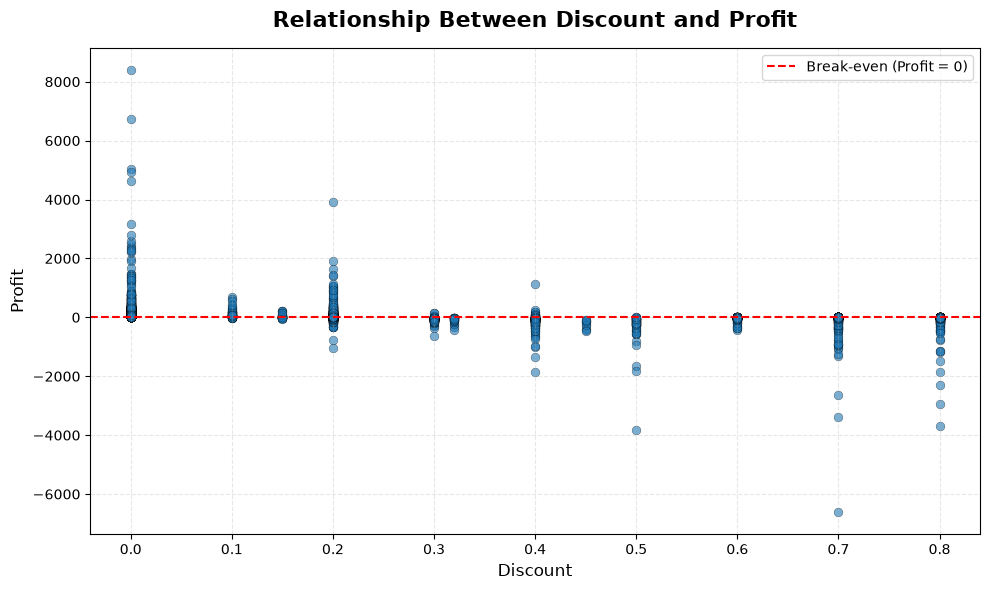

In [ ]:
plt.figure(figsize=(10,6))

plt.scatter(
    df["Discount"],
    df["Profit"],
    alpha=0.6,
    s=40,
    edgecolors="black",
    linewidths=0.3
)

# Reference line at zero profit
plt.axhline(
    y=0,
    color="red",
    linestyle="--",
    linewidth=1.5,
    label="Break-even (Profit = 0)"
)

plt.title(
    "Relationship Between Discount and Profit",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.xlabel(
    "Discount",
    fontsize=12
)

plt.ylabel(
    "Profit",
    fontsize=12
)

plt.grid(
    linestyle="--",
    alpha=0.3
)

plt.legend()

plt.tight_layout()

plt.show()

### 📌 Observation

- Most profitable orders are concentrated at **low or zero discount** levels, where several transactions generate high positive profits.
- As the **discount percentage increases**, the number of **loss-making orders** also increases, with many observations falling below the **break-even (Profit = 0)** line.
- High discount levels (particularly around **50% to 80%**) are associated with several significant negative-profit transactions.
- Although a few highly discounted orders still generate positive profits, they are relatively rare compared to low-discount orders.
- Overall, the scatter plot indicates a **negative relationship between discount and profit**, suggesting that excessive discounting can reduce profitability.

# 📈 Sales vs Profit

Analyzing the relationship between sales and profit helps us understand whether higher sales consistently lead to higher earnings. While increased sales often contribute to greater profit, factors such as discounts, costs, and product margins can significantly influence profitability.

This visualization helps us analyze:

- The relationship between sales and profit.
- Whether higher sales always result in higher profits.
- The distribution of profitable and loss-making orders.
- Patterns, trends, and potential outliers in the data.
- Opportunities to improve profitability while maintaining strong sales performance.

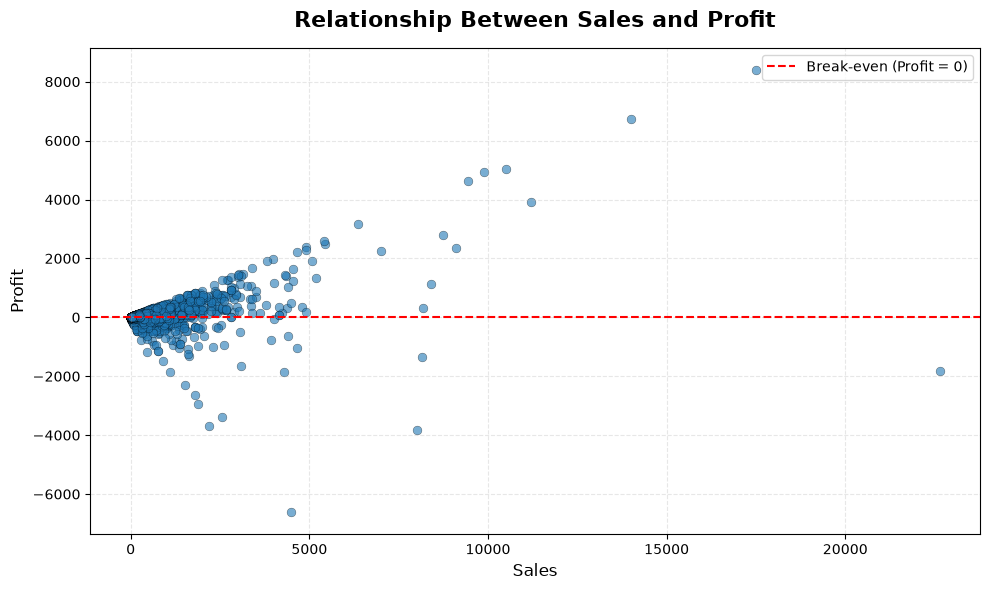

In [54]:
plt.figure(figsize=(10,6))

plt.scatter(
    df["Sales"],
    df["Profit"],
    alpha=0.6,
    s=40,
    edgecolors="black",
    linewidths=0.3
)

# Reference line at zero profit
plt.axhline(
    y=0,
    color="red",
    linestyle="--",
    linewidth=1.5,
    label="Break-even (Profit = 0)"
)

plt.title(
    "Relationship Between Sales and Profit",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.xlabel(
    "Sales",
    fontsize=12
)

plt.ylabel(
    "Profit",
    fontsize=12
)

plt.grid(
    linestyle="--",
    alpha=0.3
)

plt.legend()

plt.tight_layout()

plt.show()

### 📌 Observation

- The scatter plot shows a **generally positive relationship** between sales and profit, as many high-sales orders also generate higher profits.
- Most orders are concentrated in the **lower sales range**, with profits clustered around the break-even line.
- A few **high-sales orders generate exceptionally high profits**, indicating the presence of premium or highly profitable products.
- Several observations fall **below the break-even (Profit = 0)** line, demonstrating that some orders result in losses despite generating sales.
- The presence of both profitable and loss-making high-value orders suggests that **sales alone do not determine profitability**. Factors such as discounts, product costs, and profit margins also play an important role.

# 💼 Business Insights

Based on the exploratory data analysis, the following key business insights were identified:

- **Technology** is the highest-performing product category in terms of both **sales and profit**, making it the primary revenue driver.
- The **West** region generates the highest sales, while the **South** region has the lowest sales, indicating opportunities for regional growth.
- The **Consumer** segment contributes the largest share of total sales, followed by the Corporate and Home Office segments.
- **Standard Class** is the most preferred shipping mode, suggesting that customers generally prioritize cost-effective delivery options.
- A small number of products contribute a significant portion of the company's total sales, highlighting the importance of maintaining inventory for top-selling products.
- Higher discount levels are often associated with lower or negative profits, indicating that excessive discounting can reduce profitability.
- Although sales and profit show a generally positive relationship, **high sales do not always guarantee high profits**, emphasizing the importance of effective pricing and cost management.

# 📌 Key Takeaways

This project demonstrated how **Matplotlib** can be used to perform exploratory data analysis (EDA) and uncover meaningful business insights from real-world sales data.

Through this analysis, we learned how to:

- Analyze sales and profit trends to understand overall business performance.
- Compare product categories based on revenue and profitability.
- Evaluate regional sales performance and identify growth opportunities.
- Understand customer purchasing behavior across different market segments.
- Analyze shipping mode preferences and their impact on order distribution.
- Identify the top-performing products that contribute significantly to total sales.
- Explore the relationships between **discount, sales, and profit** using scatter plots.
- Interpret data visualizations to support business decision-making with actionable insights.
- Create clear, informative, and professional visualizations using **Matplotlib**.

# 📝 Practice Exercises

Try the following exercises:

1. Identify the top 5 customers by total sales.
2. Compare profit across different states.
3. Visualize monthly order counts.
4. Create a pie chart showing category-wise sales.
5. Compare average discounts across customer segments.
6. Find the most profitable products.
7. Analyze sales by sub-category.
8. Build your own business dashboard using Matplotlib.

# 🎯 Conclusion

In this notebook, we explored a real-world Superstore dataset using **Matplotlib**.

We performed exploratory data analysis, visualized important business metrics, and extracted meaningful insights that could support data-driven decision-making.

This project demonstrates how Matplotlib can be used effectively for business reporting and lays the foundation for creating more advanced dashboards with Seaborn, Plotly, and Bokeh.

# 🎉 Thank You

Thank you for exploring this project!

This notebook demonstrated how data visualization with **Matplotlib** can transform raw sales data into meaningful business insights. By combining statistical analysis with clear visualizations, we gained a deeper understanding of sales performance, profitability, customer behavior, and business trends.

I hope this project provides valuable insights and serves as a useful reference for anyone learning **Exploratory Data Analysis (EDA)** and **Data Visualization with Python**.

⭐ If you found this project helpful, consider giving the repository a star on GitHub!

Happy Coding! 🚀